In [57]:
H = [0.958, 1.054, 1.112, 1.186, 1.211, 1.266, 1.282, 1.301,
     1.327, 1.349, 1.377, 1.4, 1.426, 1.445, 1.465, 1.481]
R = [-6.225, -5.526, -5.38, -5.146, -5.079, -4.947, -4.924, -4.883,
     -4.827, -4.778, -4.734, -4.669, -4.634, -4.602, -4.563, -4.526]


16-element Vector{Float64}:
 -6.225
 -5.526
 -5.38
 -5.146
 -5.079
 -4.947
 -4.924
 -4.883
 -4.827
 -4.778
 -4.734
 -4.669
 -4.634
 -4.602
 -4.563
 -4.526

In [6]:
import Pkg; Pkg.add("LaTeXStrings")


   Resolving package versions...
    Updating `~/.julia/environments/v1.12/Project.toml`
  [b964fa9f] + LaTeXStrings v1.4.0
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
Precompiling packages...
   5243.5 ms  ? ApproxFun
   6467.2 ms  ? TracyWidomBeta


In [58]:
using Plots, LsqFit, LaTeXStrings

In [59]:
linfit(x,p) = @. (x*p[1]+p[2])
fiit = curve_fit(linfit, H[6:end], R[6:end], [2.1, 0.3])

LsqFit.LsqFitResult{Vector{Float64}, Vector{Float64}, Matrix{Float64}, Vector{Float64}, Vector{LsqFit.LMState{LsqFit.LevenbergMarquardt}}}([1.9649142584559671, -7.435867152145018], [-0.0012857009397633234, 0.007152927195531511, 0.0034862981061953846, -0.001425931173949735, -0.0071978174879197, 0.003819781748848783, -0.015987190306664623, 0.00010058041319105371, 0.00543395132385438, 0.005732236492973719, 0.00017086462826831905], [1.2660000000016647 0.9999999999938005; 1.2819999999839968 0.9999999999938005; … ; 1.464999999996531 0.9999999999938005; 1.4809999999788634 0.9999999999938005], true, Iter     Function value   Gradient norm 
------   --------------   --------------
, Float64[])

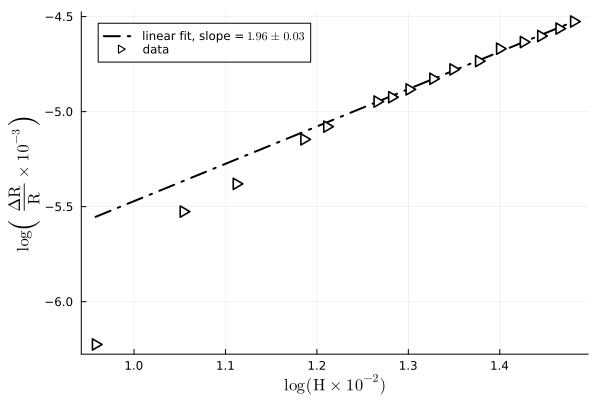

In [60]:
plot(H,linfit(H,fiit.param), label=L"linear fit, slope = $1.96\pm 0.03$", linestyle=:dashdot, c="black", lw=2)
scatter!(H,R, label="data", marker=:rtriangle, markercolor=RGBA(1, 1, 1, 0), ms=8, markerstrokewidth=2, xlabel=L"\log (\mathrm{H}\times 10^{-2})", ylabel=L"\log \left(\frac{\Delta \mathrm{R}}{ \mathrm{R}}\times 10^{-3}\right)", left_margin=3Plots.mm)

In [56]:
savefig("magrest.pdf")

"/home/shaggy1304/IISER/IISER_Courses/PH4103/Expt4/magrest.pdf"

In [14]:
fiit.param

2-element Vector{Float64}:
  1.9649142584559671
 -7.435867152145018

In [16]:
standard_errors(fiit)

2-element Vector{Float64}:
 0.029808639531064617
 0.041026229549068524

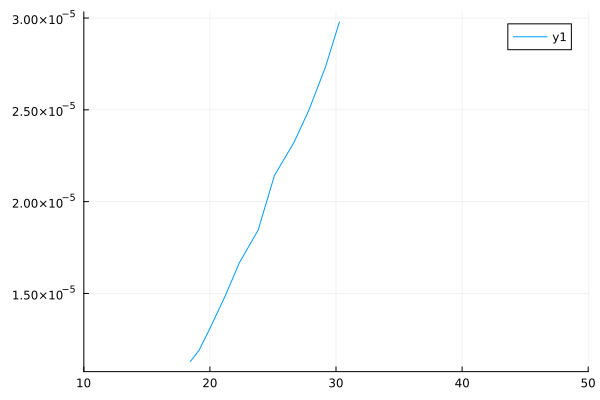

In [62]:
plot(10 .^(H)[6:end], 10 .^(R)[6:end],xlim=[10,50])

In [43]:
x = [0.01, 0.24, 0.51, 0.66, 1.1, 1.47, 1.8, 2.28, 2.59, 3.02]

y = [50, 188, 364, 459, 747, 971, 1192, 1525, 1715, 1980]

fiit = curve_fit(linfit, x,y, [2.1, 0.3])


LsqFit.LsqFitResult{Vector{Float64}, Vector{Float64}, Matrix{Float64}, Vector{Int64}, Vector{LsqFit.LMState{LsqFit.LevenbergMarquardt}}}([646.2806501208235, 34.98807063494043], [-8.549122863851338, 2.095426663938042, 0.5912021965604026, 2.533299714683892, -1.1032142321537322, 14.020626312550917, 6.293240852422741, -16.49204708958223, -6.1450455521269305, 6.755633999827296], [0.009999999999849683 1.0000000000144833; 0.24000000000365482 0.9999999999809462; … ; 2.59000000004277 1.0000000004504634; 3.020000000016335 1.0000000004504634], true, Iter     Function value   Gradient norm 
------   --------------   --------------
, Int64[])

In [45]:
fiit.param

2-element Vector{Float64}:
 646.2806501208235
  34.98807063494043

In [46]:
standard_errors(fiit)

2-element Vector{Float64}:
 2.95726677186653
 4.982902368577631

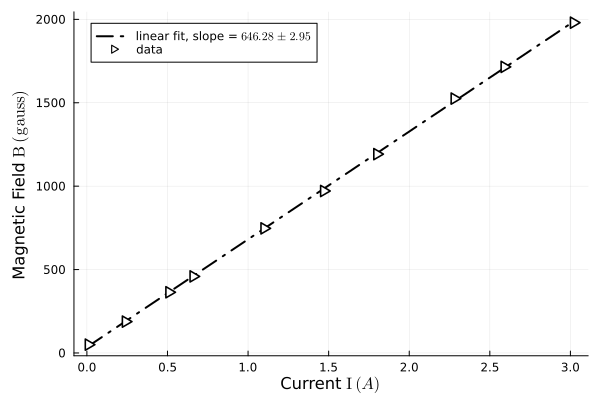

In [50]:
plot(x,linfit(x,fiit.param), label=L"linear fit, slope = $646.28\pm 2.95$", linestyle=:dashdot, c="black", lw=2)
scatter!(x,y, label="data", marker=:rtriangle, markercolor=RGBA(1, 1, 1, 0), ms=8, markerstrokewidth=2, xlabel=L"Current $\mathrm{I} \ (A)$", ylabel=L"Magnetic Field $\mathrm{B} \ (\mathrm{gauss})$", left_margin=3Plots.mm, xticks=0:0.5:3)

In [51]:
savefig("calibration.pdf")

"/home/shaggy1304/IISER/IISER_Courses/PH4103/Expt4/calibration.pdf"